In [3]:
##############
## INITIATE ##
##############

## Imports
import numpy as np
import os
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## Import modules
from f_dataset import SegmentationDataset
from f_dataset import augment
# from f_model import UNet as Model
from f_model_transformer import UNetTransformer as Model
from f_train import train 
from f_train import test

#
###

In [4]:
####################
## INITIATE MODEL ##
####################

## Parameters
path_to_dataset = '/Users/user/Documents/projects/GlandSeg/data/SEGG/images/test_tiles/'
pt_model_in = 'models/TransUNet_V1_0_90.pth'
# thresholds = np.array([0, 150, 255]) # (Background/stroma, epithelia/lumen)
thresholds = np.array([0, 150, 210, 255]) # (Background/stroma, epithelia, lumen)
batch_size = 1
num_classes = 3

## Create dataset and dataloader
dataset = SegmentationDataset(path_to_dataset, thresholds, transform=None)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

## Load model
device = "mps"
print(f"Using {device} device")
model = Model(n_classes=num_classes).to(device)
if os.path.exists(pt_model_in):
    model.load_state_dict(torch.load(pt_model_in))
    print("Loaded model")

def mps_to_numpy(X):
    images = []
    for x in X:
        x = x.cpu().numpy()
        x = x.swapaxes(0, 1).swapaxes(1, 2)
        x = x.astype('uint8')        
        images += [x]        
    return images

#
###

Using mps device
Loaded model


/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_16016/3040136.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(pt_model_in))


In [5]:
######################
## COMPUTE EXAMPLES ##
######################

## Example of iterating through the DataLoader
images = []
masks = []
preds = []
k = 0
with torch.no_grad():
    for X, Y in dataloader:
        X, Y = X.to(device), Y.to(device)    
        # print(Y.size())

        ## Inputs
        images += [mps_to_numpy(X)[0]]
        
        ## Outputs    
        Yhat = model(X)        
        Yhat = torch.sigmoid(Yhat) * 255 # Logits to probabilities to [0, 255]
        # Yhat = Yhat[:, [1, 2, 3], :, :] # When channel 0 is background
        Yhat = mps_to_numpy(Yhat)[0]
        Yhat = np.argmax(Yhat, axis=2).reshape(Yhat.shape[0], Yhat.shape[1], 1) # Only for multiple classes
        preds += [Yhat]

        ## Target
        Y = Y[:, None, :, :] # Only for CrossEntropy loss
        masks += [mps_to_numpy(Y)[0]]        
        
        k += 1
        if k > 16:
            break

#
###

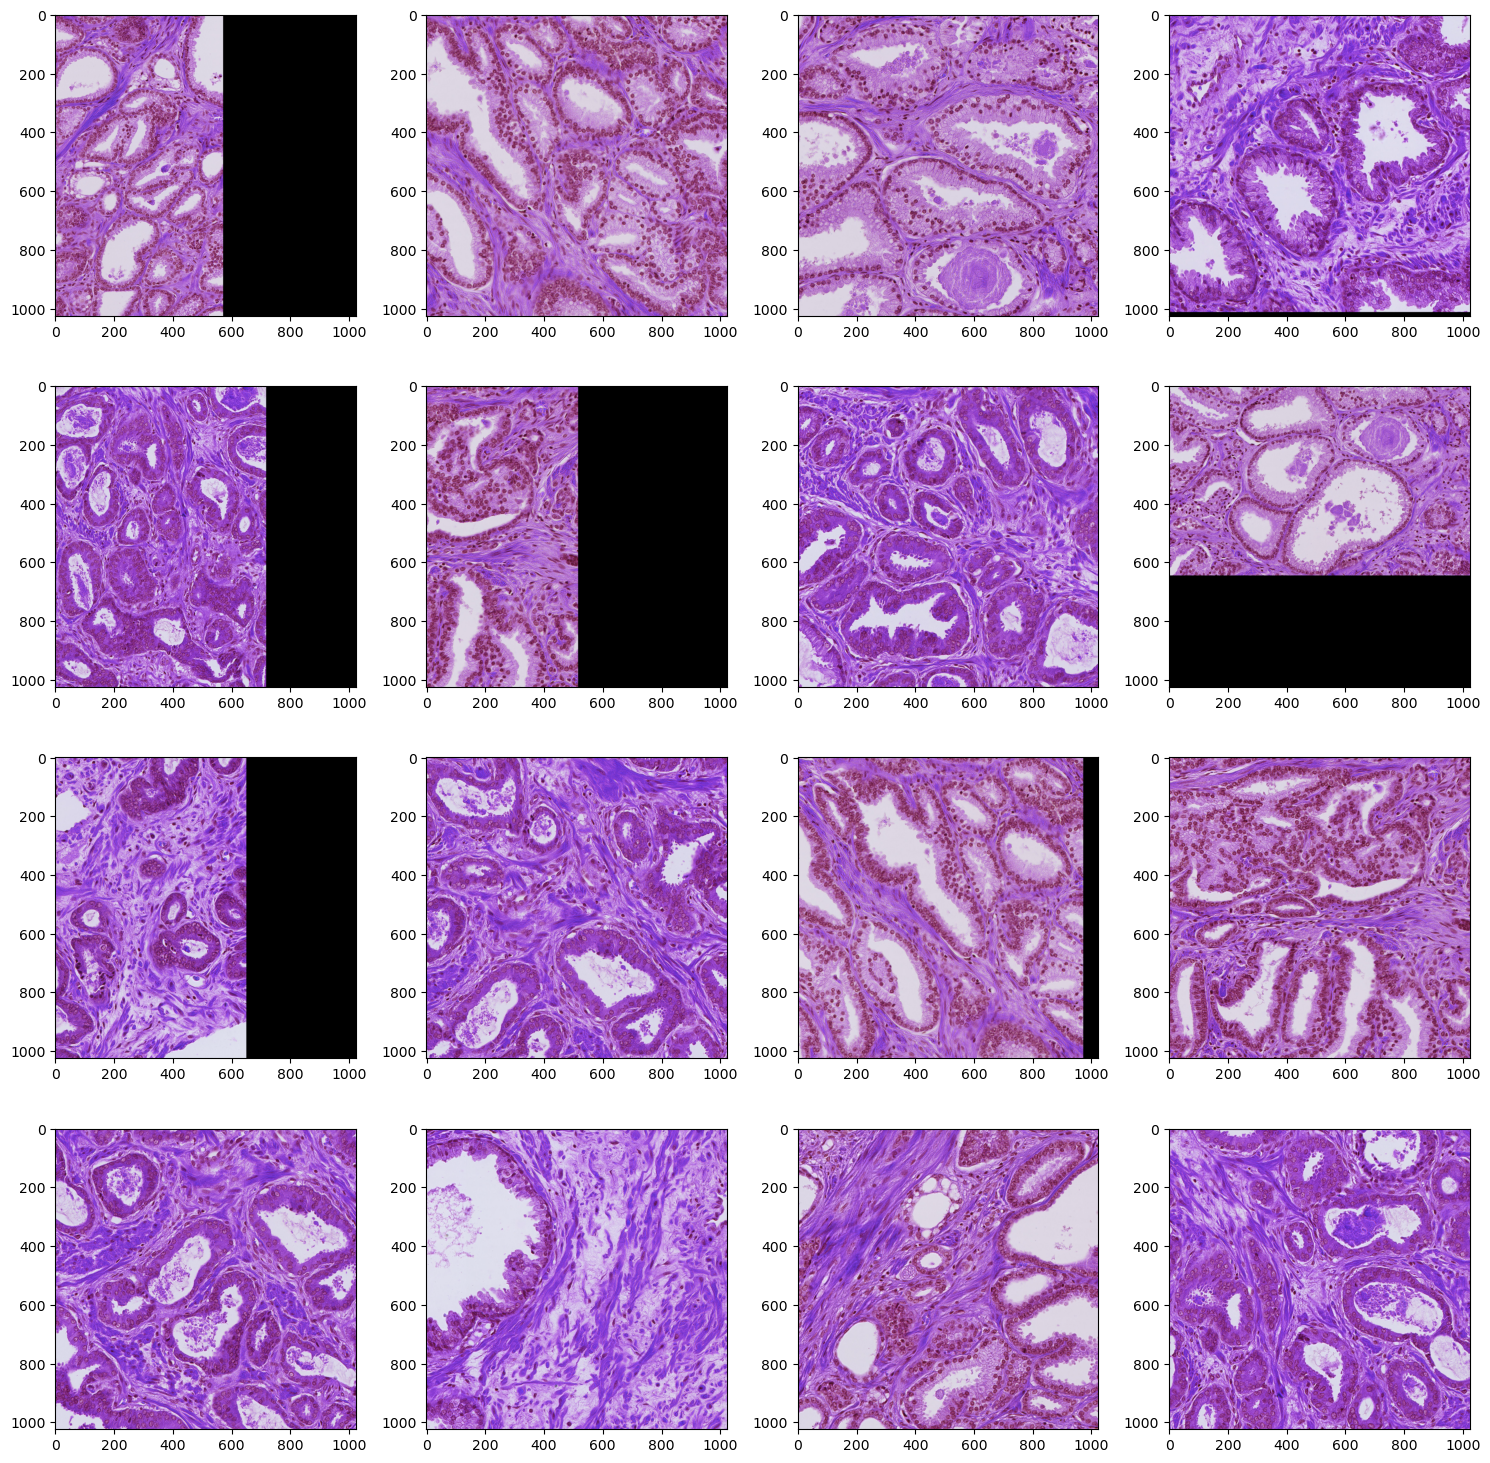

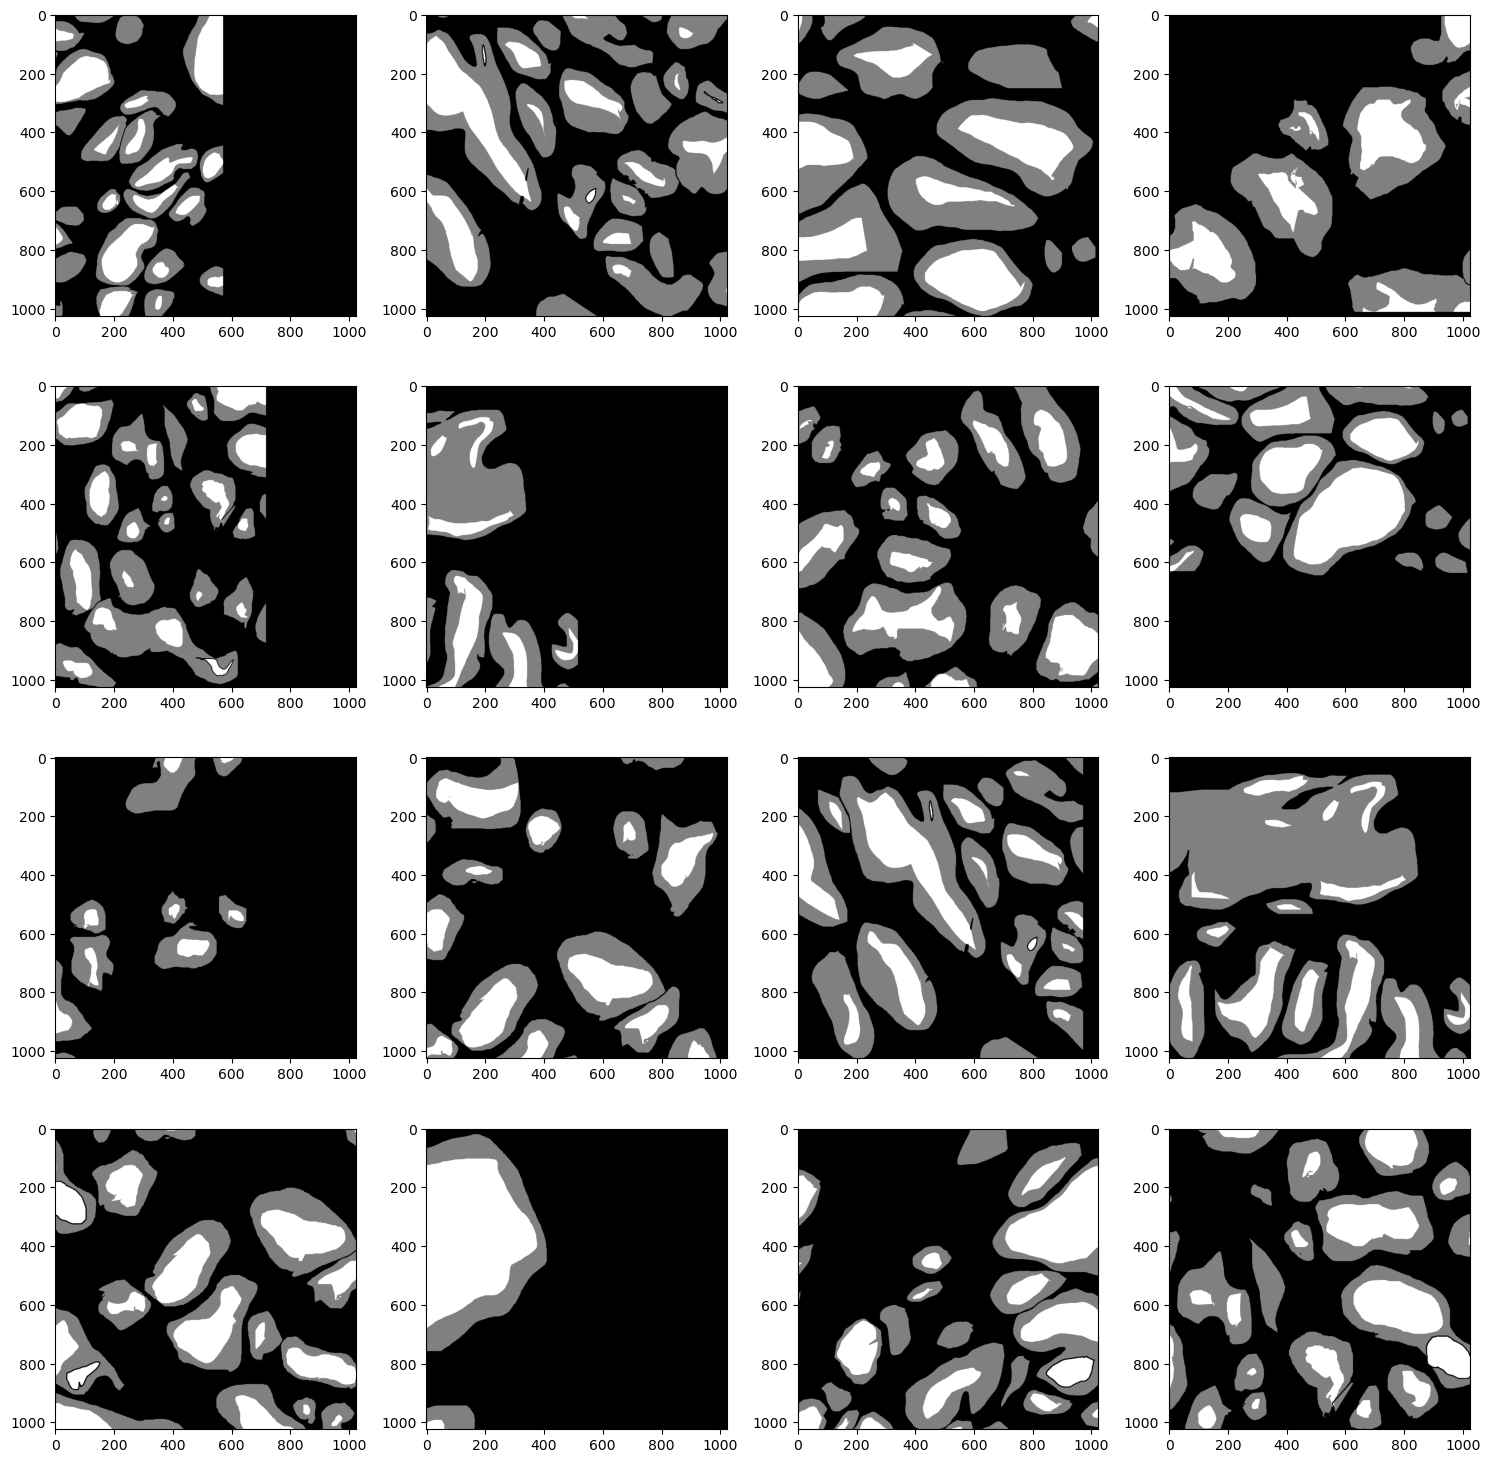

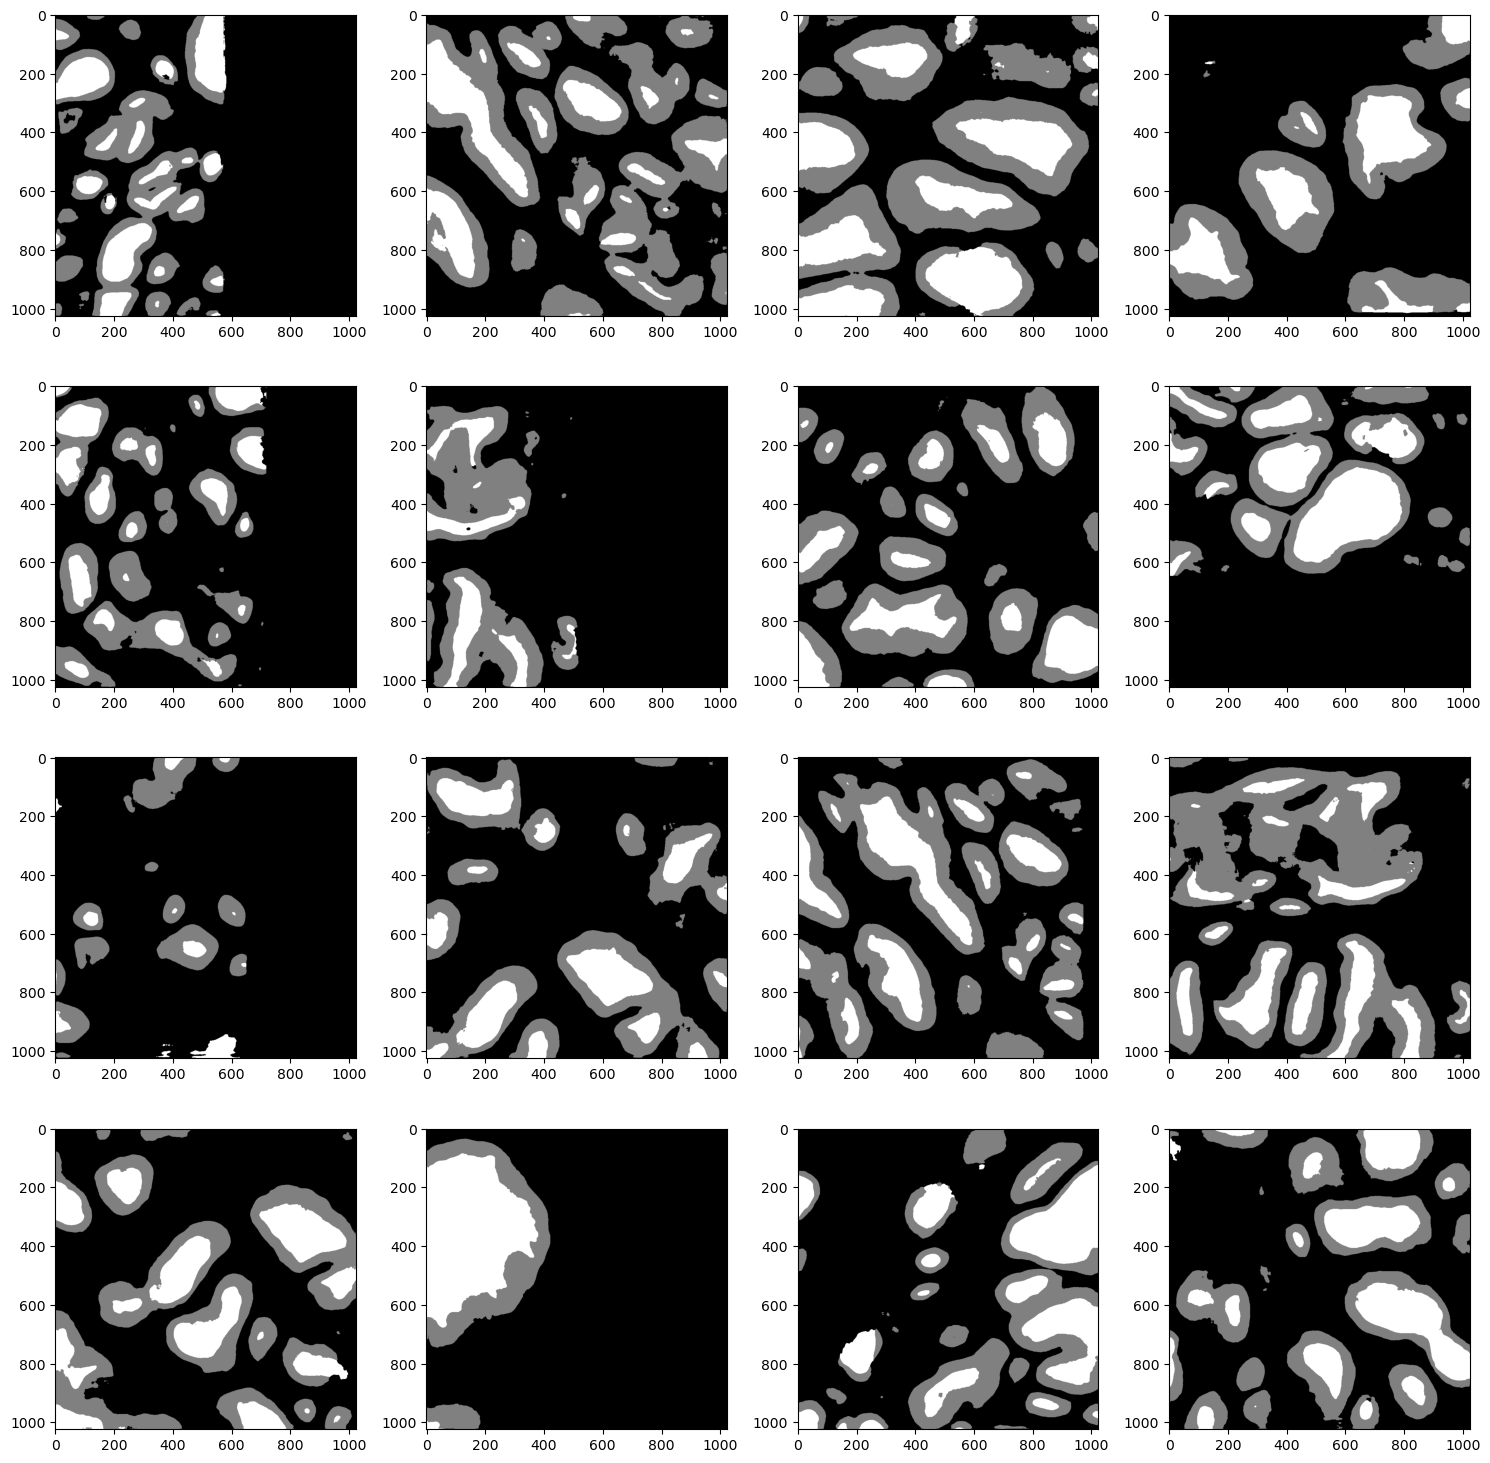

In [6]:
###########################
## VISUALISE PREDICTIONS ##
###########################

## Graphical parameters
from matplotlib.colors import ListedColormap
custom_cmap = 'gist_gray' # ListedColormap(['pink', 'hotpink', 'ivory'])

## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(15,15))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]        
        axis.imshow(images[k], cmap=custom_cmap)
        k += 1
plt.tight_layout()
plt.show()
plt.close()

## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(15,15))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]
        axis.imshow(masks[k], cmap=custom_cmap)
        k += 1
plt.tight_layout()
plt.show()
plt.close()

## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(15,15))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]
        axis.imshow(preds[k], cmap=custom_cmap)        
        k += 1
plt.tight_layout()
plt.show()
plt.close()

#
###

In [7]:
###############
## FUNCTIONS ##
###############

## Import modules
from f_train import dice_metric

## compute_dice_scores
## Goal:
## Compute DICE scores for each channel and combined classes from the predictions and targets in a dataloader.
## Inputs:
## dataloader (torch.utils.data.DataLoader): Dataloader containing the input data and target labels.
## device (torch.device): Device on which the model is running (e.g., 'cpu' or 'cuda').
## Outputs:
## dice_scores (list of lists): A list containing DICE scores for each channel and combined classes.
def compute_dice_scores(dataloader, device):

    ## Collect DICE scores
    dice_scores = []
    with torch.no_grad():
        for X, Y in dataloader:
    
            ## Load batch
            X, Y = X.to(device), Y.to(device)    
            
            ## Outputs
            Yhat = model(X)                
            Yhat = torch.sigmoid(Yhat) * 255 # Logits to probabilities to [0, 255]
            Yhat = mps_to_numpy(Yhat)[0]
            Yhat = np.argmax(Yhat, axis=2).reshape(Yhat.shape[0], Yhat.shape[1], 1) # Only for multiple classes        
    
            ## Target
            Y = Y[:, None, :, :] # Only for CrossEntropy loss
            Y = mps_to_numpy(Y)[0]
    
            ## DICE per channel
            dice_scores_ = []
            for i in range(3):
                dice_scores_ += [dice_metric(Yhat == i, Y == i)]
            dice_scores_ += [dice_metric((Yhat == 1) | (Yhat == 2), (Y == 1) | (Y == 2))] # Class 1 or 2
    
            ## Collect dice_scores_
            dice_scores += [dice_scores_]

    ## End
    return dice_scores

#
###

In [8]:
#################################
## COMPUTE DICE FOR EACH CLASS ##
#################################

## Parameters
thresholds = np.array([0, 150, 210, 255]) # (Background/stroma, epithelia, lumen)
batch_size = 1
num_classes = 3
PT_ROOT = '/Users/user/Documents/projects/'

In [10]:
## Create dataset and dataloader
path_to_dataset = PT_ROOT + 'GlandSeg/data/SEGG/images/train_tiles/'
dataset = SegmentationDataset(path_to_dataset, thresholds, transform=None)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
dice_scores_train = compute_dice_scores(dataloader, device)

## Create dataset and dataloader
path_to_dataset = PT_ROOT + 'GlandSeg/data/SEGG/images/val_tiles/'
dataset = SegmentationDataset(path_to_dataset, thresholds, transform=None)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
dice_scores_val = compute_dice_scores(dataloader, device)

## Create dataset and dataloader
path_to_dataset = PT_ROOT + 'GlandSeg/data/SEGG/images/test_tiles/'
dataset = SegmentationDataset(path_to_dataset, thresholds, transform=None)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
dice_scores_test = compute_dice_scores(dataloader, device)

## Extract scores for each class
train_class_1 = [scores[0] for scores in dice_scores_train]
train_class_2 = [scores[1] for scores in dice_scores_train]
train_class_3 = [scores[2] for scores in dice_scores_train]
train_class_4 = [scores[3] for scores in dice_scores_train]

val_class_1 = [scores[0] for scores in dice_scores_val]
val_class_2 = [scores[1] for scores in dice_scores_val]
val_class_3 = [scores[2] for scores in dice_scores_val]
val_class_4 = [scores[3] for scores in dice_scores_val]

test_class_1 = [scores[0] for scores in dice_scores_test]
test_class_2 = [scores[1] for scores in dice_scores_test]
test_class_3 = [scores[2] for scores in dice_scores_test]
test_class_4 = [scores[3] for scores in dice_scores_test]

#
###

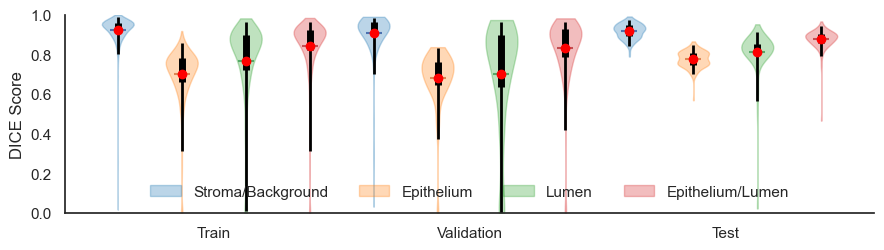

In [11]:
###################
## VISUALISATION ##
###################

## Function to calculate IQR and 95% interval
def calculate_iqr_95_interval(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = [q1, q3]

    lower_95 = np.percentile(data, 2.5)
    upper_95 = np.percentile(data, 97.5)
    interval_95 = [lower_95, upper_95]

    return iqr, interval_95

## Table
results_mean = []
results_iqr = []
results_interval_95 = []

## Plotting violin plots
plt.figure(figsize=(9, 3))

## Figure style
import seaborn as sns
sns.set_theme(style="white")  # Use 'white' theme for a clean look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

## Updated colors to include the fourth class
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Different colors for each class, including Epithelium/Lumen

## Violin plots for Class 1 (stroma/background)
positions1 = [1, 5, 9]
vp1 = plt.violinplot([train_class_1, val_class_1, test_class_1], positions=positions1, showmeans=True, showextrema=True)
for pc in vp1['bodies']:
    pc.set_facecolor(colors[0])  # Color for class 1
    pc.set_edgecolor(colors[0])

# Violin plots for Class 2 (epithelium)
positions2 = [2, 6, 10]
vp2 = plt.violinplot([train_class_2, val_class_2, test_class_2], positions=positions2, showmeans=True, showextrema=True)
for pc in vp2['bodies']:
    pc.set_facecolor(colors[1])  # Color for class 2
    pc.set_edgecolor(colors[1])

## Violin plots for Class 3 (lumen)
positions3 = [3, 7, 11]
vp3 = plt.violinplot([train_class_3, val_class_3, test_class_3], positions=positions3, showmeans=True, showextrema=True)
for pc in vp3['bodies']:
    pc.set_facecolor(colors[2])  # Color for class 3
    pc.set_edgecolor(colors[2])

## Violin plots for Class 4 (Epithelium/Lumen)
positions4 = [4, 8, 12]
vp4 = plt.violinplot([train_class_4, val_class_4, test_class_4], positions=positions4, showmeans=True, showextrema=True)
for pc in vp4['bodies']:
    pc.set_facecolor(colors[3])  # Color for class 4
    pc.set_edgecolor(colors[3])

## Adding vertical lines for IQR and 95% intervals
datasets = [(train_class_1, val_class_1, test_class_1),
            (train_class_2, val_class_2, test_class_2),
            (train_class_3, val_class_3, test_class_3),
            (train_class_4, val_class_4, test_class_4)]

## Updated positions to include the fourth class
positions = [positions1, positions2, positions3, positions4]

## Calculate and plot the mean points for each class
for dataset, pos, color in zip(datasets, positions, colors):
    for data, p in zip(dataset, pos):
        mean = np.mean(data)
        plt.scatter(p, mean, color='red', zorder=3)  # Add a black point at the mean
        ## Collect
        results_mean += [mean]

## Adding vertical lines for IQR and 95% intervals
for dataset, pos in zip(datasets, positions):
    for data, p in zip(dataset, pos):
        iqr, interval_95 = calculate_iqr_95_interval(data)
        # IQR lines
        plt.vlines(p, iqr[0], iqr[1], color='black', linewidth=5)
        # 95% interval lines
        plt.vlines(p, interval_95[0], interval_95[1], color='black', linewidth=2)
        ## Collect
        results_iqr += [iqr]
        results_interval_95 += [interval_95]

## Adjusting min/max to only show vertical bars
for key in ['cbars', 'cmins', 'cmaxes']:
    vp1[key].set_visible(False)
    vp2[key].set_visible(False)
    vp3[key].set_visible(False)
    vp4[key].set_visible(False)

## Plot labels and legend
plt.xticks([2.5, 6.5, 10.5], ['Train', 'Validation', 'Test'])
plt.ylabel('DICE Score')
plt.ylim(0, 1)  # DICE scores range from 0 to 1

## Adding custom legend for all four classes
plt.legend([vp1['bodies'][0], vp2['bodies'][0], vp3['bodies'][0], vp4['bodies'][0]], 
           ['Stroma/Background', 'Epithelium', 'Lumen', 'Epithelium/Lumen'], 
           loc='lower center', frameon=False, ncol=4)  # Adjusted to ncol=4 for the new class

## Removing overall plot title
plt.suptitle('')  
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout
plt.show()

#
###

In [12]:
print(np.round(results_mean,2))
print(np.round(results_iqr,2))
print(np.round(results_interval_95,2))

[0.92 0.91 0.92 0.7  0.68 0.77 0.76 0.7  0.81 0.84 0.83 0.88]
[[0.91 0.96]
 [0.89 0.96]
 [0.89 0.94]
 [0.66 0.78]
 [0.64 0.76]
 [0.75 0.81]
 [0.72 0.9 ]
 [0.63 0.9 ]
 [0.8  0.85]
 [0.82 0.92]
 [0.79 0.93]
 [0.86 0.9 ]]
[[0.8  0.99]
 [0.7  0.98]
 [0.84 0.97]
 [0.31 0.86]
 [0.37 0.83]
 [0.7  0.84]
 [0.01 0.96]
 [0.   0.96]
 [0.56 0.91]
 [0.31 0.96]
 [0.42 0.96]
 [0.79 0.94]]


In [6]:
###########
## DEBUG ##
###########

In [81]:
index = np.argwhere(np.array(train_class_4) <= 0.5).flatten()
print(index)

[   1   16   22   23   27   29   30   31   33   34   35   43  112  116
  131  185  192  193  212  228  233  312  332  333  347  348  352  525
  529  536  540  555  570  599  634  636  637  644  647  648  649  652
  656  657  661  664  667  672  741  766  769  777  785  873  900 1140
 1141 1142 1144 1151 1171 1172 1183 1187 1192 1247 1281 1302 1381 1582
 1583 1791 1798 1925 1934 1984 1986 1988 1994 2020 2028 2029 2032 2033
 2036 2038 2047 2049 2148 2153 2155 2245 2262 2264 2280 2284 2286 2317]


In [82]:
## Create dataset and dataloader
path_to_dataset = PT_ROOT + 'GlandSeg/data/SEGG/images/train_tiles/'
dataset = SegmentationDataset(path_to_dataset, thresholds, transform=None)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [83]:
print(dataset.image_paths[555])
print(dataset.mask_paths[555])

/Users/user/Documents/projects/GlandSeg/data/SEGG/images/train_tiles/EU_7189_16_2D_HandE_TissueTrain_(1.00,42715,26030,13790,9645)/reference/EU_7189_16_2D_HandE_TissueTrain_(1.00,42715,26030,13790,9645)_2049,1.png
/Users/user/Documents/projects/GlandSeg/data/SEGG/images/train_tiles/EU_7189_16_2D_HandE_TissueTrain_(1.00,42715,26030,13790,9645)/mask/EU_7189_16_2D_HandE_TissueTrain_(1.00,42715,26030,13790,9645)_2049,1.png


In [84]:
inputs = []
predictions = []
targets = []
with torch.no_grad():
    for index_ in index:
    
        ## Input and target
        input_, target_ = dataloader.dataset[index_]
        input_ = input_[None, :, :, :].to(device)
        target_ = target_[None, :, :].to(device)
        print(input_.shape)
        print(target_.shape)
        
        ## Inputs
        inputs += [mps_to_numpy(input_)[0]]
        
        ## Outputs    
        Yhat = model(input_)        
        Yhat = torch.sigmoid(Yhat) * 255 # Logits to probabilities to [0, 255]
        # Yhat = Yhat[:, [1, 2, 3], :, :] # When channel 0 is background
        Yhat = mps_to_numpy(Yhat)[0]
        Yhat = np.argmax(Yhat, axis=2).reshape(Yhat.shape[0], Yhat.shape[1], 1) # Only for multiple classes
        predictions += [Yhat]
    
        ## Target
        target_ = target_[:, None, :, :] # Only for CrossEntropy loss
        targets += [mps_to_numpy(target_)[0]]        

torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024])
torch.Size([1, 3, 1024, 1024])
torch.Size([1, 1024, 1024

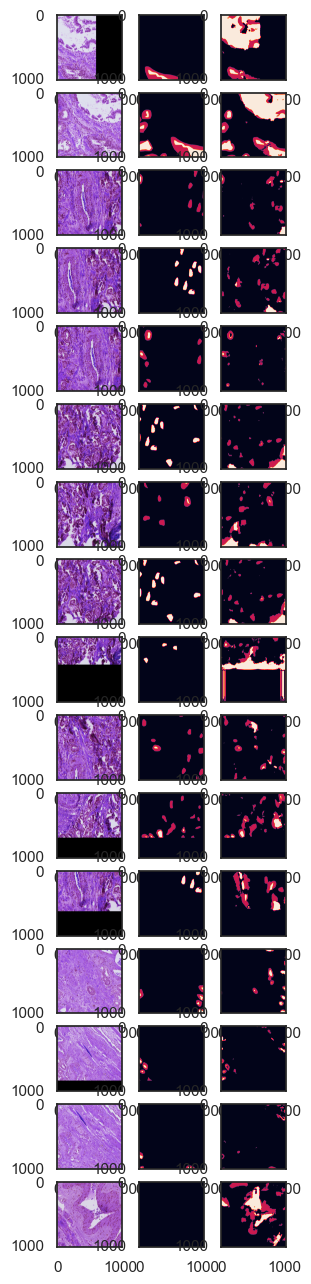

In [85]:
num_samples = 16
fig, axes = plt.subplots(num_samples, 3, figsize=(3, num_samples))
for i in range(num_samples):
    axes[i,0].imshow(inputs[i])
    axes[i,1].imshow(targets[i])
    axes[i,2].imshow(predictions[i])
plt.show()
plt.tight_layout()
plt.close()

In [ ]:
#
### END DEBUG